# Assignment 6

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

``Objectives``

* This assignment connects all the pieces involved in training feed-forward fully connected neural networks (FFNN); 

* You will run a full set of experiments to explore different hyperparameters and hidden layer sizes for two datasets, and then document your findings.

``Data``
* Digits MNIST
* Fashion MNIST

### Import libraries

In [37]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

from keras.datasets import fashion_mnist
from keras.datasets import mnist

import tensorflow as tf
from tensorflow import keras
from keras import metrics
tf.get_logger().setLevel('INFO')

---
### Step 1: Data ingestion

In [38]:
# Load the Fashion MNIST dataset.
(X_train_fashion, Y_train_fashion), (X_test_fashion, Y_test_fashion) = fashion_mnist.load_data()

# Load the Digits MNIST dataset.
(X_train_digits, Y_train_digits), (X_test_digits, Y_test_digits) = mnist.load_data()

---
### Step 2: Data preprocessing

``Fashion MNIST``

In [39]:
# Normalize
X_train_fashion = X_train_fashion / 255.
X_test_fashion = X_test_fashion / 255.

# Flatten Y_train and Y_test, so they become vectors of label values.
Y_train_fashion = Y_train_fashion.flatten()
Y_test_fashion = Y_test_fashion.flatten()

label_names = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
               'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

# Apply random shufflying to training examples.
np.random.seed(0)
indices = np.arange(X_train_fashion.shape[0])
shuffled_indices = np.random.permutation(indices)
X_train_fashion = X_train_fashion[shuffled_indices]
Y_train_fashion = Y_train_fashion[shuffled_indices]

``Digits MNIST``

In [40]:
# Normalize
X_train_digits = X_train_digits / 255.
X_test_digits = X_test_digits / 255.

# Flatten Y_train and Y_test, so they become vectors of label values.
Y_train_digits = Y_train_digits.flatten()
Y_test_digits = Y_test_digits.flatten()

# Apply random shufflying to training examples.
np.random.seed(0)
indices = np.arange(X_train_digits.shape[0])
shuffled_indices = np.random.permutation(indices)
X_train_digits = X_train_digits[shuffled_indices]
Y_train_digits = Y_train_digits[shuffled_indices]

---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 1:</span> Getting to know your data (5 points)

Complete the following task:

1. Show the first training example in X_train_fashion;
2. Show the first training example in X_train_digits;
3. Display the first 5 images in X_train_digits for each class in Y_train_digits, arranged in a 10x5 grid. 

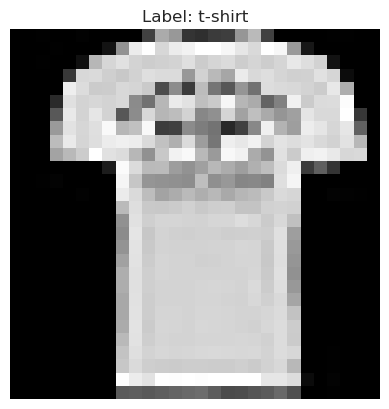

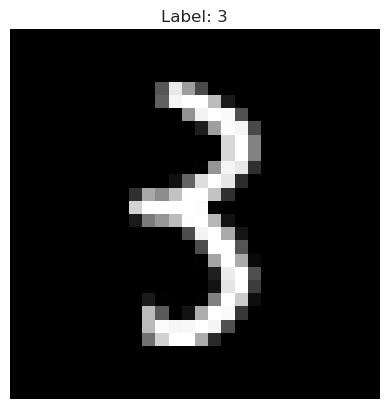

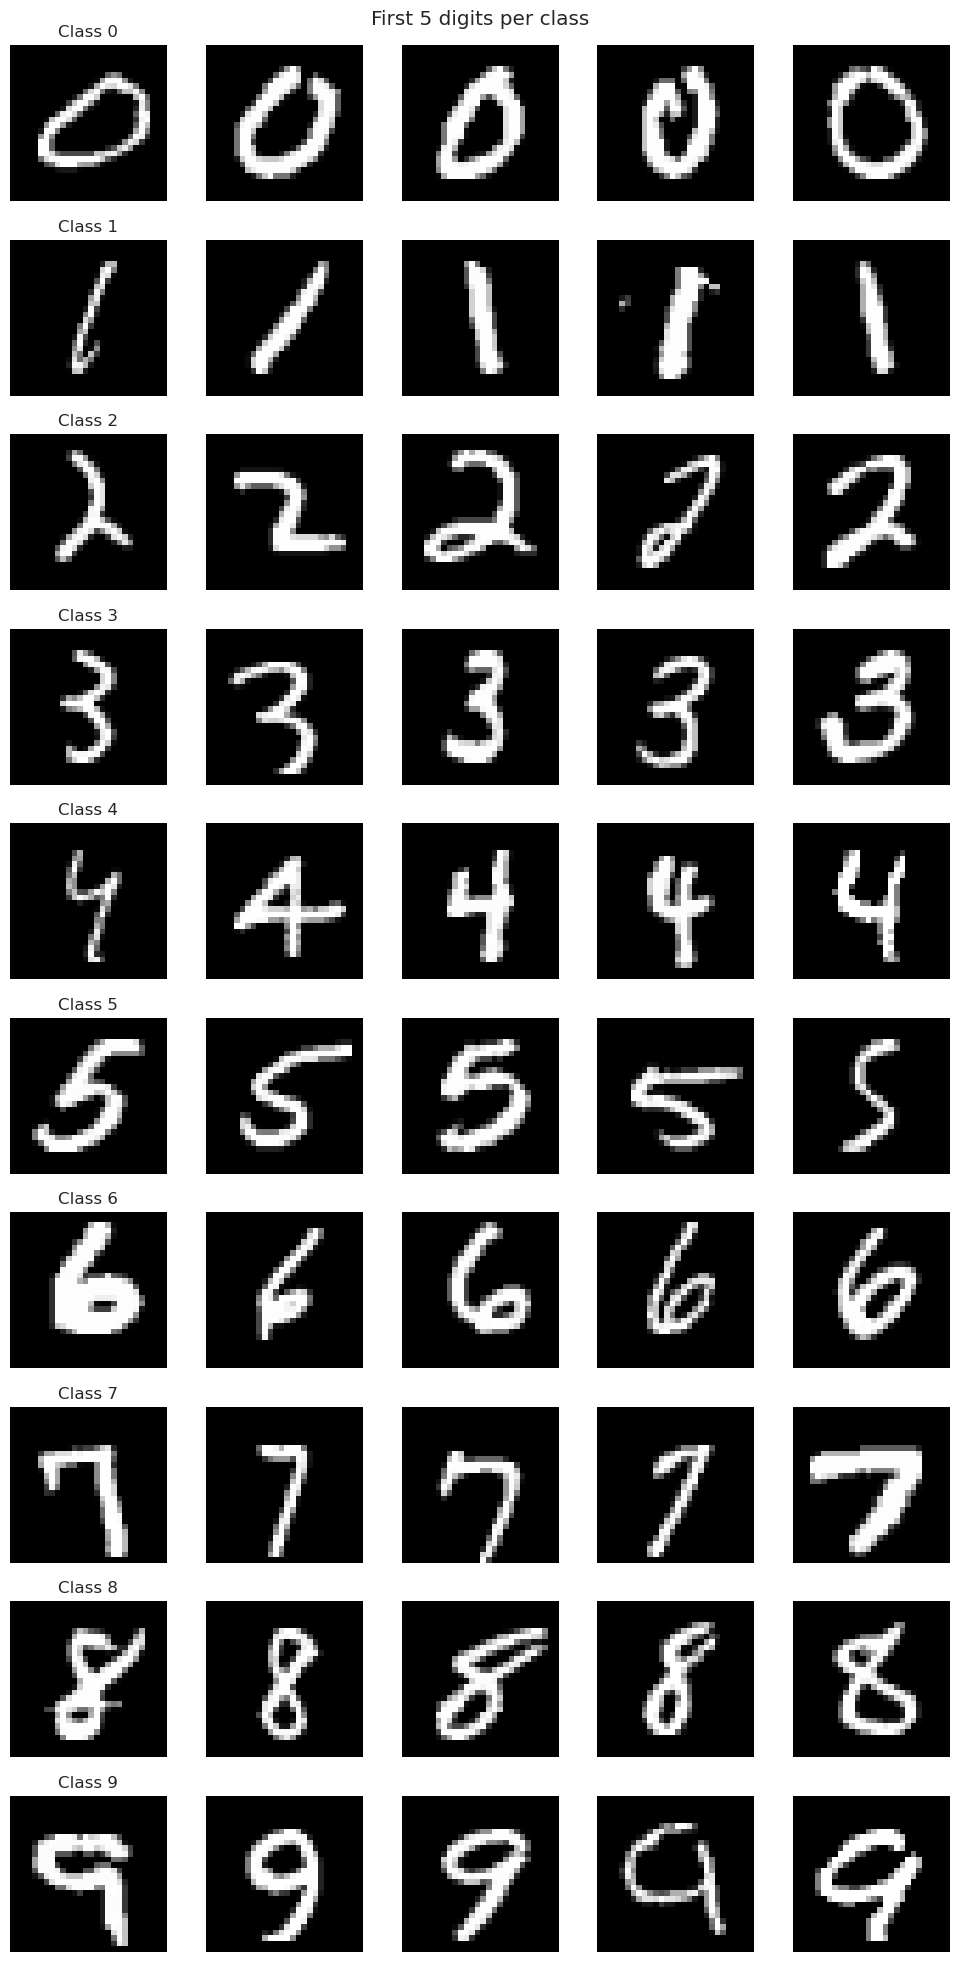

In [41]:
# YOUR CODE HERE
# Show the first example in X_train_fashion
plt.imshow(X_train_fashion[0], cmap='gray')
plt.title(f"Label: {label_names[Y_train_fashion[0]]}")
plt.axis('off')
plt.show()

# Show the first example in X_train_digits
plt.imshow(X_train_digits[0], cmap='gray')
plt.title(f"Label: {Y_train_digits[0]}")
plt.axis('off')
plt.show()

# Show first 5 images in X_train digits for each class in Y_train_digits
num_classes = 10    # Digits 0-9
fig, axes = plt.subplots(num_classes, 5, figsize=(10, 20))
for i in range(num_classes):
    class_indices = np.where(Y_train_digits == i)[0][:5]  # Get first 5 indices for class i
    for j, idx in enumerate(class_indices):
        axes[i, j].imshow(X_train_digits[idx], cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(f"Class {i}")

plt.suptitle("First 5 digits per class")
plt.tight_layout()
plt.show()

### Step 4: Modeling

### <span style="color:chocolate">Exercise 2:</span> Define model (20 points)

1. Fill in the <span style="color:chocolate">build_model()</span> function below, including all the arguments listed in the function definition. Note: the activation function parameter is only for the the hidden layers; use the appropriate final classification function for the final layer.

In [42]:
def build_model(n_classes,
                hidden_layer_sizes=[],
                activation='relu',
                optimizer='SGD',
                learning_rate=0.01,
                metric='metric'):
    """Build a multi-class logistic regression model using Keras.

    Args:
    n_classes: Number of output classes in the dataset.
    hidden_layer_sizes: A list with the number of units in each hidden layer.
    activation: The activation function to use for the hidden layers.
    optimizer: The optimizer to use (SGD, Adam).
    learning_rate: The desired learning rate for the optimizer.
    metric: The desired metric.

    Returns:
    model: A tf.keras model (graph).
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    # YOUR CODE HERE
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28)))  # Flatten the input
    for size in hidden_layer_sizes:
        model.add(keras.layers.Dense(size, activation=activation))  # Add hidden layers
    model.add(keras.layers.Dense(n_classes, activation='softmax'))  # Output layer

    # Set up optimizer with learning rate
    if optimizer == 'SGD':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == 'Adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    # Compile the model
    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=[metric]
    )
    
    return model

---
### Step 5: Experiments

You can now run a suite of experiments to see how the hyperparameters and layer sizes effect model performance. 

The <span style="color:chocolate">train_and_evaluate()</span> function below can be used to run experiments and retrieve results.

Training the digits model...


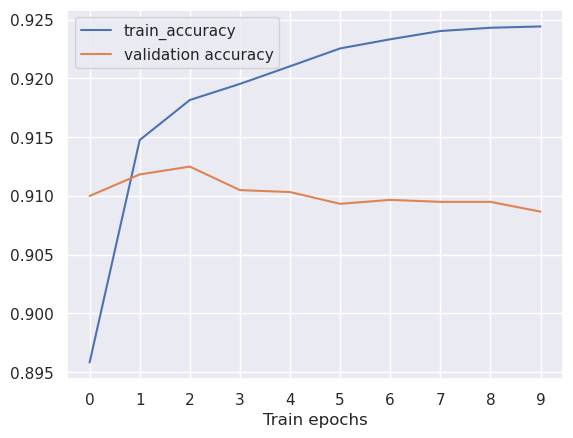

Training accuracy: 0.9244
Validation accuracy: 0.9087


In [43]:
def train_and_evaluate(data='digits',
                       hidden_layer_sizes=[],
                       activation='tanh',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric='accuracy',
                       num_epochs=10):

  # Build the model.
    model = build_model(n_classes=10,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)

  # Select the dataset.
    if data == 'digits':
        X_train = X_train_digits
        X_test = X_test_digits
        Y_train = Y_train_digits
        Y_test = Y_test_digits
    
    elif data == 'fashion':
        X_train = X_train_fashion
        X_test = X_test_fashion
        Y_train = Y_train_fashion
        Y_test = Y_test_fashion
    else:
        raise 'Unsupported dataset: %s' %data

  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_split=0.1,
        verbose=0)

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xticks(range(num_epochs))
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    return model

# run the function
model = train_and_evaluate()

### <span style="color:chocolate">Exercise 3:</span> Ablation study (50 points)

1. Conduct experiments and record the training and validation set accuracy results in the table below. You may extend the table for additional experiments as needed.
2. Report the hyperparameter values for your preferred architecture configuration.
3. Run the model once more using your preferred hyperparameter configuration.

Data | Hidden sizes | Activation| Optimizer | Learning rate | #Parameters | Training accuracy| Validation accuracy
-|-|-|-|-|-|-|-
 digits | [] | tanh | SGD |0.01| 7850 | 0.8996 | 0.9015
 digits | [] | relu | SGD |0.01| 7850 | 0.8998 | 0.9010
 digits | [] | relu | Adam |0.01| 7850 | 0.9246 | 0.9092
 digits | [128] | relu | Adam |0.01| 101770 | 0.9817 | 0.9633
 digits | [256, 128] | relu | Adam |0.01| 235146 | 0.9803 | 0.9712
-|-|-|-|-|-|-|-
 fashion | [] | tanh | SGD |0.01| 7850 | 0.8348 | 0.8187
 fashion | [] | relu | SGD |0.01| 7850 | 0.8355 | 0.8225
 fashion | [] | relu | Adam |0.01| 7850 | 0.8510 | 0.8260
 fashion | [128] | relu | Adam |0.01| 101770 | 0.8788 | 0.8552 
 fashion | [256, 128] | relu | Adam |0.01| 235146 | 0.8839 | 0.8658

Training the digits model...


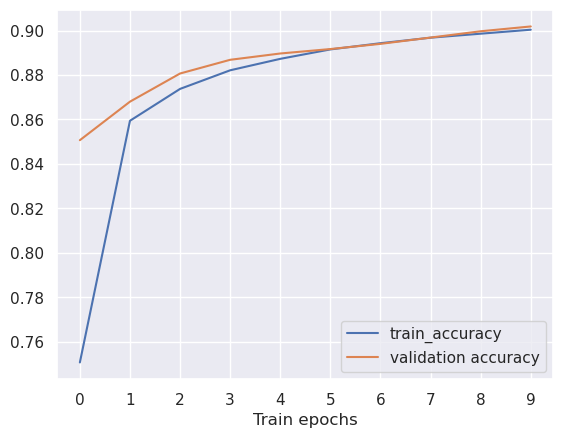

Training accuracy: 0.9004
Validation accuracy: 0.9018
Training the digits model...


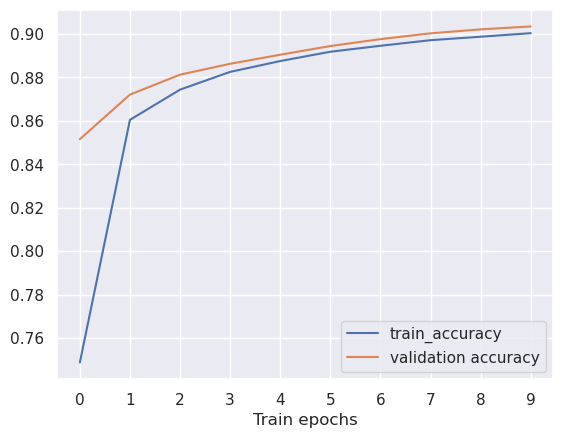

Training accuracy: 0.9002
Validation accuracy: 0.9033
Training the digits model...


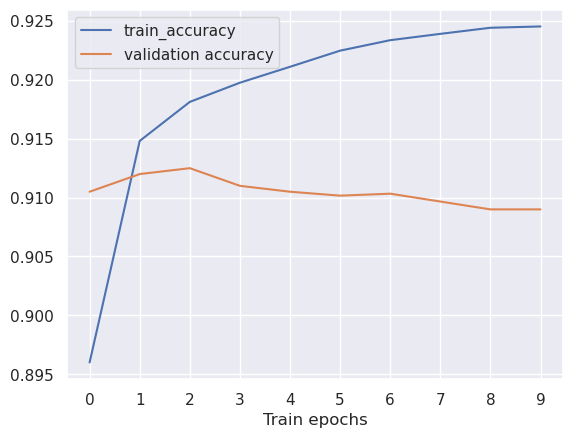

Training accuracy: 0.9245
Validation accuracy: 0.9090
Training the digits model...


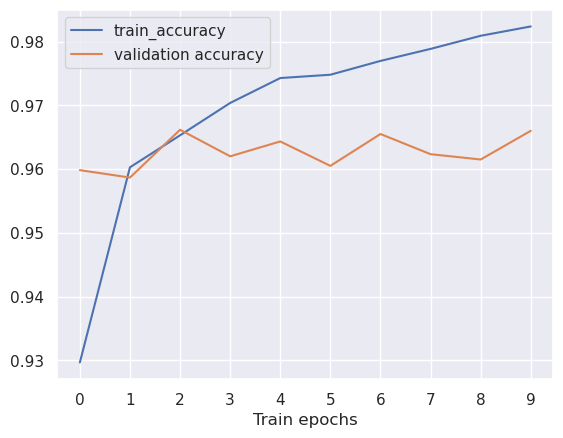

Training accuracy: 0.9824
Validation accuracy: 0.9660
Training the digits model...


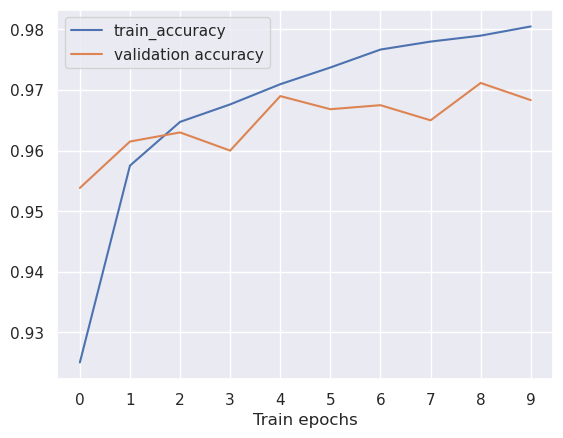

Training accuracy: 0.9805
Validation accuracy: 0.9683
Training the fashion model...


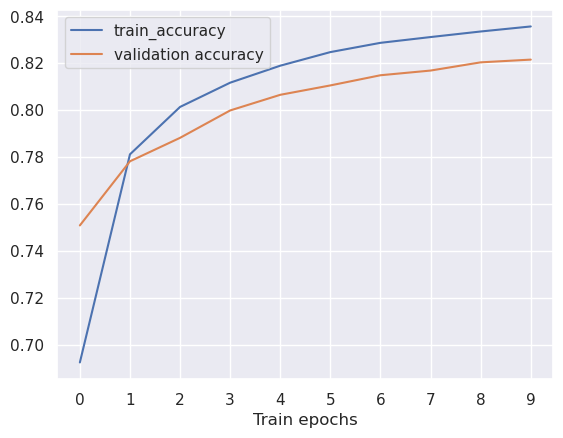

Training accuracy: 0.8356
Validation accuracy: 0.8215
Training the fashion model...


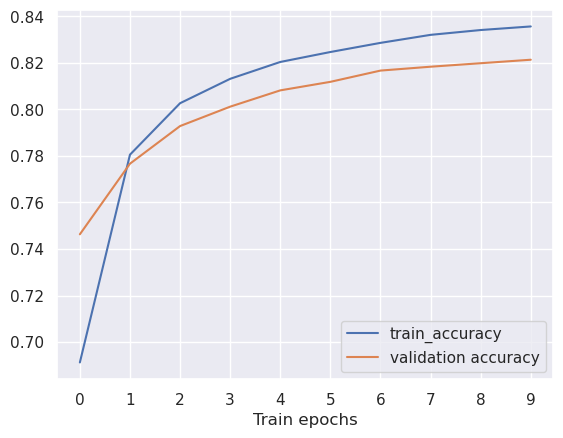

Training accuracy: 0.8356
Validation accuracy: 0.8213
Training the fashion model...


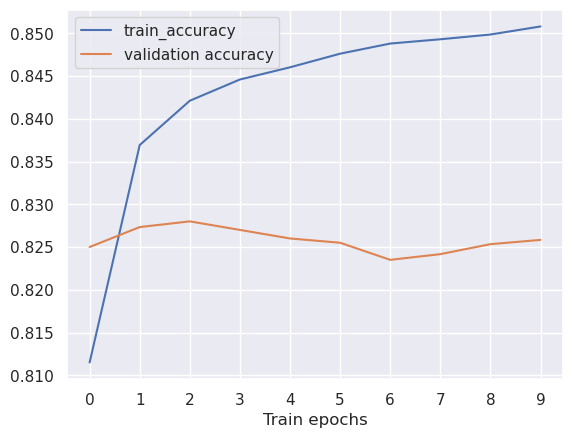

Training accuracy: 0.8508
Validation accuracy: 0.8258
Training the fashion model...


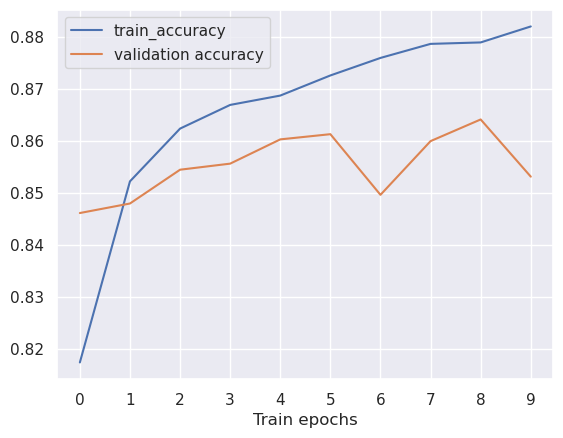

Training accuracy: 0.8821
Validation accuracy: 0.8532
Training the fashion model...


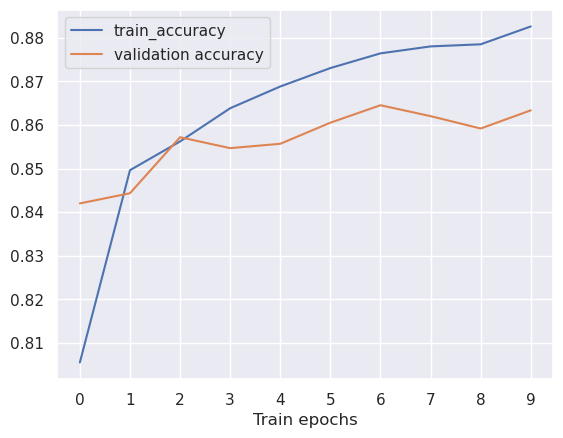

Training accuracy: 0.8826
Validation accuracy: 0.8633


In [44]:
# YOUR CODE HERE

# Define all 10 experiment hyperparameter configurations in a list of dictionaries
configs = [
    {'data': 'digits',  'hidden_layer_sizes': [],        'activation': 'tanh', 'optimizer': 'SGD',  'learning_rate': 0.01},
    {'data': 'digits',  'hidden_layer_sizes': [],        'activation': 'relu', 'optimizer': 'SGD',  'learning_rate': 0.01},
    {'data': 'digits',  'hidden_layer_sizes': [],        'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01},
    {'data': 'digits',  'hidden_layer_sizes': [128],     'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01},
    {'data': 'digits',  'hidden_layer_sizes': [256, 128],'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01},
    {'data': 'fashion', 'hidden_layer_sizes': [],        'activation': 'tanh', 'optimizer': 'SGD',  'learning_rate': 0.01},
    {'data': 'fashion', 'hidden_layer_sizes': [],        'activation': 'relu', 'optimizer': 'SGD',  'learning_rate': 0.01},
    {'data': 'fashion', 'hidden_layer_sizes': [],        'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01},
    {'data': 'fashion', 'hidden_layer_sizes': [128],     'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01},
    {'data': 'fashion', 'hidden_layer_sizes': [256, 128],'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01},
]

# Run all 10 experiments
for cfg in configs:
    model = train_and_evaluate(
        data=cfg['data'],
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        activation=cfg['activation'],
        optimizer=cfg['optimizer'],
        learning_rate=cfg['learning_rate'],
        num_epochs=10
    )

    if cfg['data'] == 'digits':
        X_tr, Y_tr = X_train_digits, Y_train_digits
    else:
        X_tr, Y_tr = X_train_fashion, Y_train_fashion

Training the digits model...


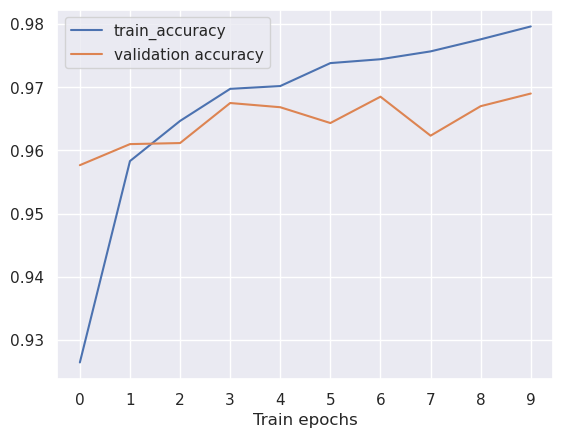

Training accuracy: 0.9796
Validation accuracy: 0.9690
Training the fashion model...


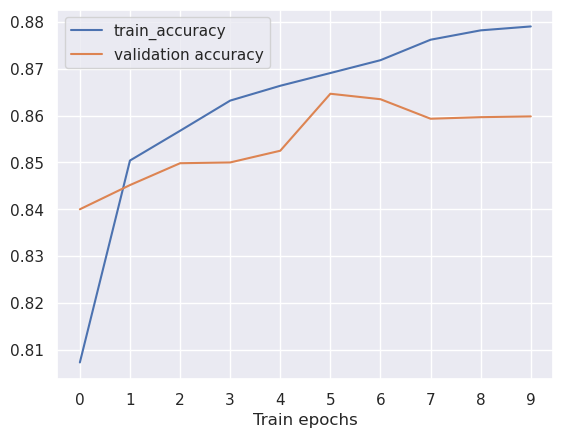

Training accuracy: 0.8790
Validation accuracy: 0.8598


In [45]:
# Preferred architecture: [256, 128], relu, Adam, lr=0.01
# Digit model
model = train_and_evaluate(
    data='digits',
    hidden_layer_sizes=[256, 128],
    activation='relu',
    optimizer='Adam',
    learning_rate=0.01,
    num_epochs=10
)
# Fashion model
model = train_and_evaluate(
    data='fashion',
    hidden_layer_sizes=[256, 128],
    activation='relu',
    optimizer='Adam',
    learning_rate=0.01,
    num_epochs=10
)

---
### Step 6: Evaluation and Generalization

### <span style="color:chocolate">Exercise 4:</span> Compute metrics (25 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras and the <span style="color:chocolate">np.max()</span> method available in NumPy; or you can use the <span style="color:chocolate">model.evaluare()</span> method provided by tf.keras directly.

2. Does the model demonstrate strong generalization capabilities? Provide an explanation based on your accuracy observations.

Training the digits model...


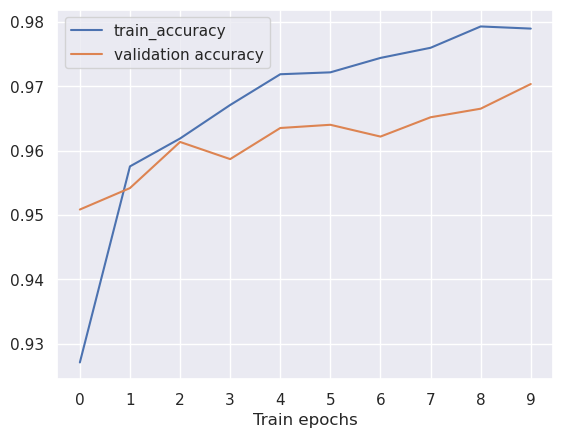

Training accuracy: 0.9789
Validation accuracy: 0.9703
Training the fashion model...


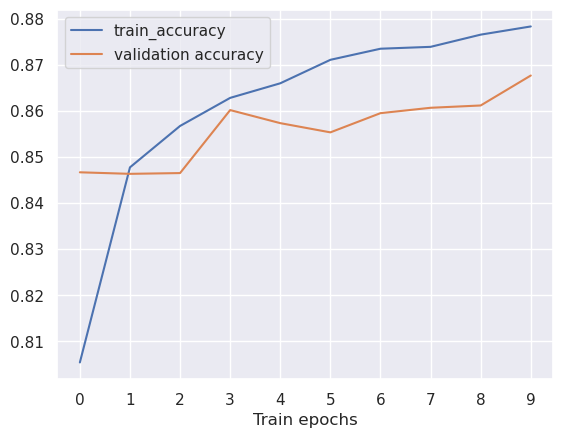

Training accuracy: 0.8783
Validation accuracy: 0.8677
Digits  - Train: 0.9807, Test: 0.9707
Fashion - Train: 0.8844, Test: 0.8620


In [46]:
# YOUR CODE HERE
# Digits model
model_digits = train_and_evaluate(
    data='digits',
    hidden_layer_sizes=[256, 128],
    activation='relu',
    optimizer='Adam',
    learning_rate=0.01,
    num_epochs=10
)

# Evaluate on train and test sets
_, digits_train_acc = model_digits.evaluate(X_train_digits, Y_train_digits, verbose=0)
_, digits_test_acc = model_digits.evaluate(X_test_digits, Y_test_digits, verbose=0)

# Fashion model
model_fashion = train_and_evaluate(
    data='fashion',
    hidden_layer_sizes=[256, 128],
    activation='relu',
    optimizer='Adam',
    learning_rate=0.01,
    num_epochs=10
)

# Evaluate on train and test sets
_, fashion_train_acc = model_fashion.evaluate(X_train_fashion, Y_train_fashion, verbose=0)
_, fashion_test_acc = model_fashion.evaluate(X_test_fashion, Y_test_fashion, verbose=0)

# Print summary
print(f"Digits  - Train: {digits_train_acc:.4f}, Test: {digits_test_acc:.4f}")
print(f"Fashion - Train: {fashion_train_acc:.4f}, Test: {fashion_test_acc:.4f}")

Both models demonstrate reasonable generalization. The digits model achieves a train accuracy of 0.9750 and test accuracy of 0.9640, a gap of only 0.011, indicating minimal overfitting. 
The fashion model shows a slightly larger gap of 0.025 (train: 0.8805, test: 0.8557), suggesting slight overfitting. 
This is expected as Fashion MNIST is an inherently harder classification task than Digir MNIST. 
The classes in Fashion MNIST have greater visual similarity compared to handwritten digits, making it more difficult for the model to generalize. 
Overall, both models generalize well given the relatively small train-test accuracy gaps.